In [43]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF, CFT


N = 10000
K = 5
W = 0.6
MIN_S = 0.3
MAX_S = 0.95


scores = pd.DataFrame()

data = Data()
data.generate(n=N, seed=0)
data.generate_random_condition(min_s=MIN_S, max_s=MAX_S)


cf = CF(data)
algorithms = [CT(data, on="D"), CT(data, on="P"), cf, CFT(cf)]
for alg in algorithms:
    alg.fit()
    score = alg.get_topK(k=K, w=W)
    scores=pd.concat([scores, score], ignore_index=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


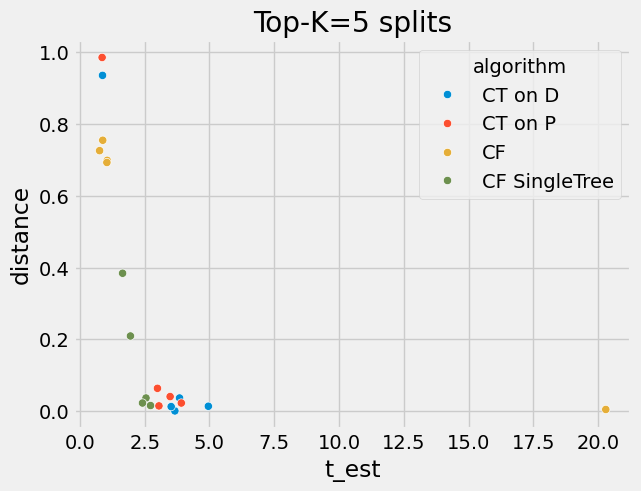

In [44]:
sns.scatterplot(data=scores, x="t_est", y="distance", hue="algorithm")
plt.title("Top-K=5 splits")
plt.show()

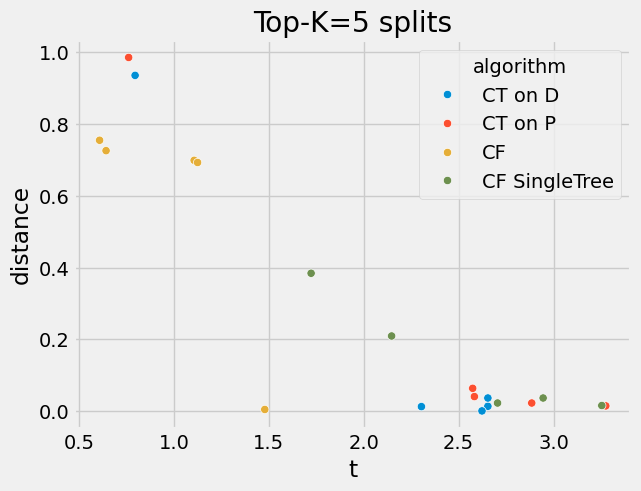

In [45]:
sns.scatterplot(data=scores, x="t", y="distance", hue="algorithm")
plt.title("Top-K=5 splits")
plt.show()

In [46]:
all_scores = pd.DataFrame()
for alg in algorithms:
    score = alg.get_topK(k=50, w=W)
    all_scores=pd.concat([all_scores, score], ignore_index=True)

for alg in algorithms:
    print(alg.algorithm, ":", all_scores[all_scores["algorithm"]==alg.algorithm].shape[0], 'splits')

CT on D : 50 splits
CT on P : 44 splits
CF : 50 splits
CF SingleTree : 30 splits


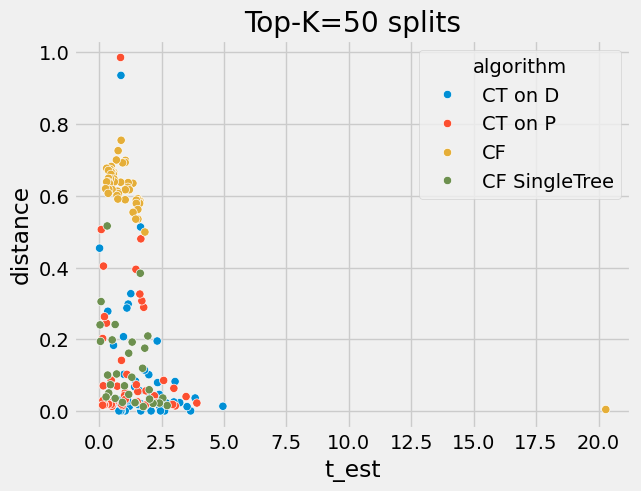

In [47]:
sns.scatterplot(data=all_scores, x="t_est", y="distance", hue="algorithm")
plt.title("Top-K=50 splits")
plt.show()

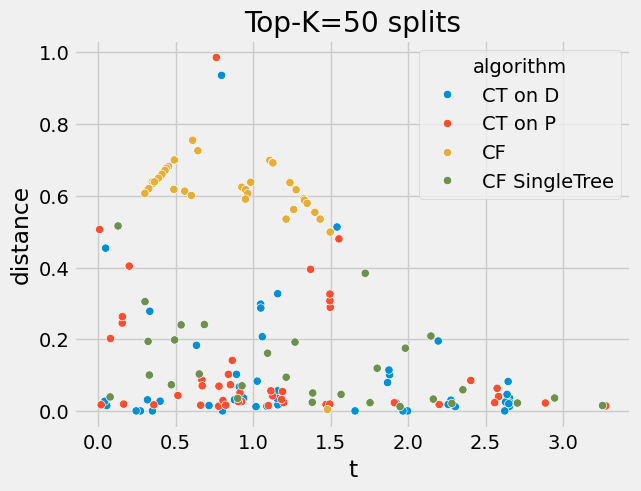

In [48]:
sns.scatterplot(data=all_scores, x="t", y="distance", hue="algorithm")
plt.title("Top-K=50 splits")
plt.show()

In [11]:
test = all_scores[all_scores["algorithm"]=="CT on D"]
test

,condition,t_est,distance,T0,T1,depth,norm_cate,score,t,features,true_score,algorithm,execution_time
0,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,4.956,0.013,-0.04,4.92,6,1.00,0.61,2.654,4.0,0.61,CT on D,NaN
1,feature_2 > -1.159,0.873,0.936,0.98,1.85,1,0.18,0.48,0.796,1.0,0.55,CT on D,NaN
2,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,3.845,0.036,0.88,4.72,5,0.78,0.48,2.654,4.0,0.61,CT on D,NaN
3,feature_2 <= -1.159 AND feature_0 > 0.499 AND ...,3.664,0.000,0.99,4.65,3,0.74,0.44,2.623,3.0,0.59,CT on D,NaN
4,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,3.521,0.012,1.04,4.56,5,0.71,0.43,2.304,4.0,0.53,CT on D,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,feature_2 > -1.159 AND feature_0 <= -0.089 AND...,0.181,0.036,1.35,1.53,5,0.04,0.04,0.858,4.0,0.21,CT on D,NaN
64,feature_2 > -1.159 AND feature_0 <= -0.089 AND...,0.224,0.012,2.17,1.94,6,0.05,0.03,0.027,5.0,0.01,CT on D,NaN
65,feature_2 <= -1.159 AND feature_0 <= 0.499 AND...,0.230,0.000,0.74,0.97,3,0.05,0.03,0.303,3.0,0.07,CT on D,NaN
66,feature_2 <= -1.159 AND feature_0 <= 0.499,0.121,0.000,0.74,0.87,2,0.02,0.01,0.286,2.0,0.06,CT on D,NaN


Text(0.5, 1.0, "User's P: feature_2 > -0.9129810751169849")

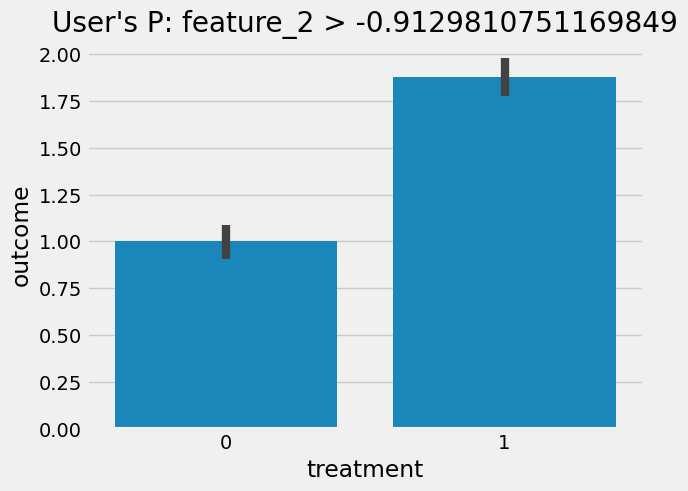

In [3]:
# visualize the user's query data.q_df where T0=1 and T1=0

# create a barplot grouping T for data.q_df
sns.barplot(x='treatment', y='outcome', data=data.q_df)
plt.title("User's P: "+ data.p)

In [57]:
import polars as pl
# in the polars dataframe q_df compute the average treatment effect
t1_data = data.q_df.filter(pl.col("treatment") == 1).select(pl.col("outcome")).mean().item()
t0_data = data.q_df.filter(pl.col("treatment") == 0).select(pl.col("outcome")).mean().item()
ate = t1_data - t0_data

print("---- ATE FROM THE DATA ----")
print("ATE:", round(ate,3))
# print("T1:", round(t1_data,2), "T0:", round(t0_data,2))


print("---- GROUND TRUTH ATE ----")
print("ATE:", round(data.q_df.select(pl.col("ITE").mean()).item(),3))



print("---- ATE FROM CF ----")
X_subpopulation = data.q_df.select(pl.exclude(["treatment", "outcome", "ITE", "id"]))

# Compute the CATE for the subpopulation
ate = cf.forest.const_marginal_ate(X_subpopulation)[0]
print("ATE:", round(ate,3)) # why should this be accurate? feature_2 is not even in the tree 


---- ATE FROM THE DATA ----
ATE: 0.877
---- GROUND TRUTH ATE ----
ATE: 0.797
---- ATE FROM CF ----
ATE: 0.875


# Recommendations from CT on D

In [78]:
top_ct_d = scores[(scores['algorithm']=='CT on D')].sort_values('score', ascending=False)
top_ct_d

,condition,t_est,distance,T0,T1,depth,norm_cate,score,t,features,true_score,algorithm,execution_time
0,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,4.956,0.01,-0.04,4.92,6,1.00,0.60,2.654,4.0,0.60,CT on D,NaN
1,feature_2 > -1.159,0.873,0.94,0.98,1.85,1,0.18,0.48,0.796,1.0,0.56,CT on D,NaN
2,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,3.845,0.04,0.88,4.72,5,0.78,0.48,2.654,4.0,0.62,CT on D,NaN
3,feature_2 <= -1.159 AND feature_0 > 0.499 AND ...,3.664,0.00,0.99,4.65,3,0.74,0.44,2.623,3.0,0.59,CT on D,NaN
4,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,3.521,0.01,1.04,4.56,5,0.71,0.43,2.304,4.0,0.52,CT on D,NaN


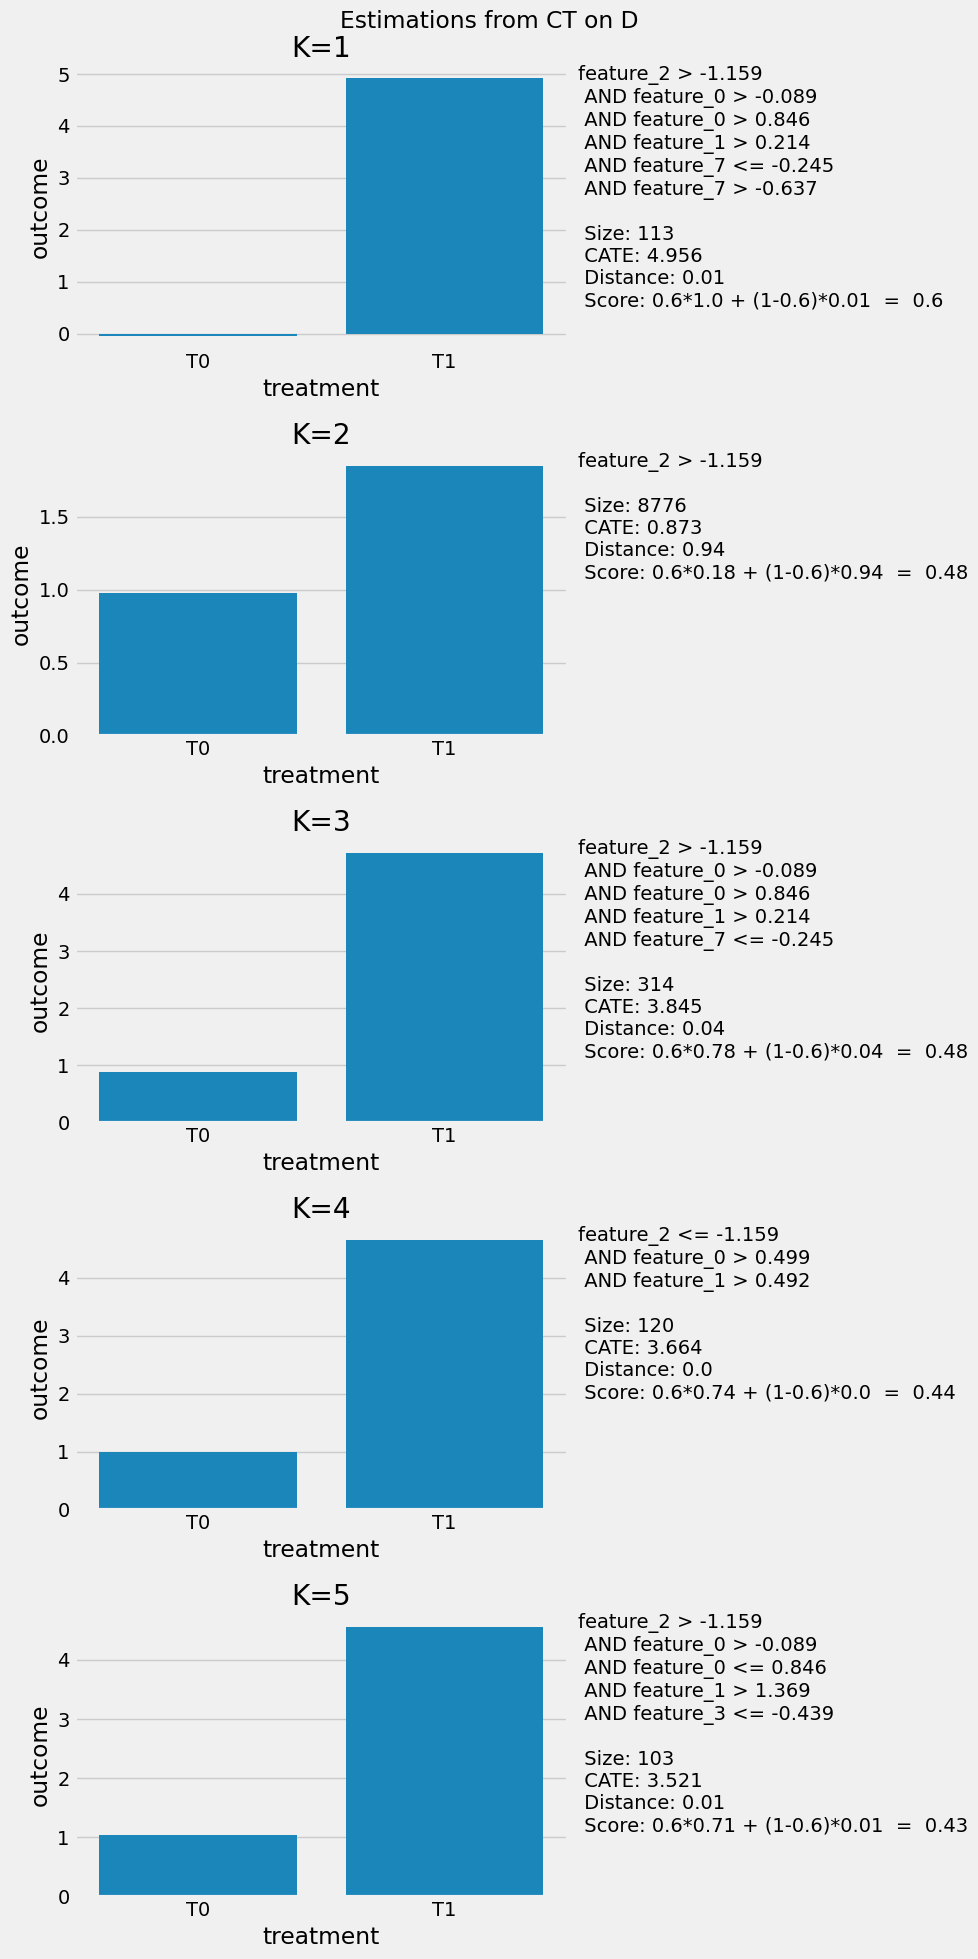

In [84]:
def visualize_recommendations(scores, k=5):
    scores = scores.sort_values('score', ascending=False)
    # for K in range(k):
    #     topK = top.iloc[K]

    #     topK['condition'] = topK['condition'].replace('AND', '\n AND')

    #     sns.barplot(x=['T0', 'T1'], y=[topK['T0'], topK['T1']])
    #     plt.title('Estimations from '+ topK['algorithm'] +', K='+str(K+1))
    #     plt.xlabel("treatment")
    #     plt.ylabel("outcome")
    #     # add a plot label with the condition top1['condition'] with extra small font
    #     plt.text(-1, -2, topK['condition'] +'\n\n Score: 0.6*'+str(topK['t_est']) + " + (1-0.6)*" +str(topK['distance']) + " = " + str(round(topK['score'],2)), fontsize=11)
    #     plt.show()


    fig, axs = plt.subplots(k, 1, figsize=(10,20), tight_layout = True)
    fig.suptitle('Estimations from '+ scores.iloc[0]['algorithm'])
    for i in range(k):
        topK = scores.iloc[i]
        dt = data.execute(topK['condition'])[['feature_0', 'feature_1']]
        topK['condition'] = topK['condition'].replace('AND', '\n AND')
        dt = pd.DataFrame(dt, columns=['feature_0', 'feature_1'])
        
        sns.barplot(x=['T0', 'T1'], y=[topK['T0'], topK['T1']], ax=axs[i])
        axs[i].set_title('K='+str(i+1))
        axs[i].set_xlabel("treatment")
        axs[i].set_ylabel("outcome")

        outer_text = f"{topK['condition']} \n\n Size: {dt.shape[0]} \n CATE: {str(topK['t_est'])} \n Distance: {str(topK['distance'])}\n Score: 0.6*{str(topK['norm_cate'])} + (1-0.6)*{str(topK['distance'])}  =  {str(round(topK['score'],2))}"
        axs[i].annotate(outer_text, xy=(1, 1), xycoords='axes fraction', xytext=(1.02, 1), textcoords='axes fraction', ha='left', va='top')
    
visualize_recommendations(top_ct_d)

# Recommendations from CT on P

In [80]:
top_ct_p = scores[(scores['algorithm']=='CT on P')].sort_values('score', ascending=False)
top_ct_p

,condition,t_est,distance,T0,T1,depth,norm_cate,score,t,features,true_score,algorithm,execution_time
5,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,3.913,0.02,1.07,4.99,6,1.00,0.61,2.885,3.0,0.54,CT on P,NaN
6,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,3.481,0.04,0.77,4.25,5,0.89,0.55,2.583,3.0,0.49,CT on P,NaN
7,feature_0 <= 2.171,0.857,0.99,0.99,1.85,1,0.22,0.53,0.762,1.0,0.54,CT on P,NaN
8,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.992,0.06,1.02,4.01,4,0.76,0.48,2.574,2.0,0.50,CT on P,NaN
9,feature_0 > 2.171,3.049,0.01,1.63,4.68,1,0.78,0.47,3.275,1.0,0.60,CT on P,NaN


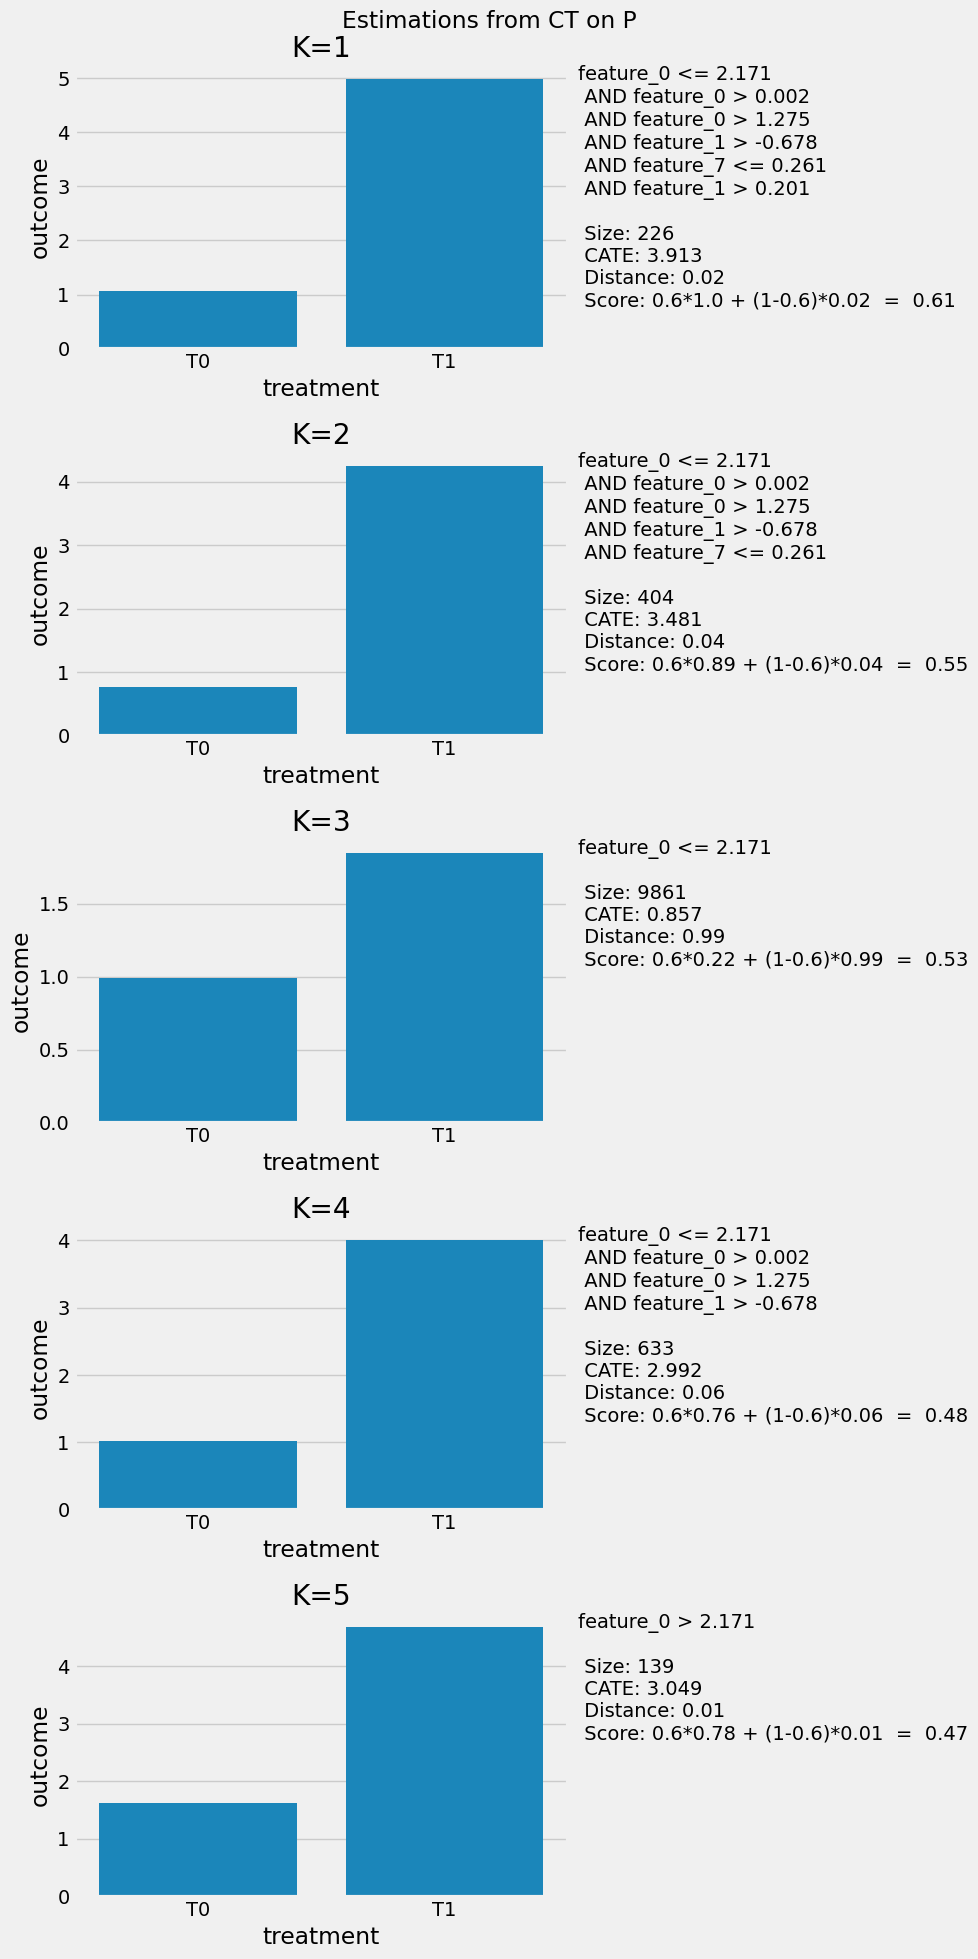

In [85]:
visualize_recommendations(top_ct_p)

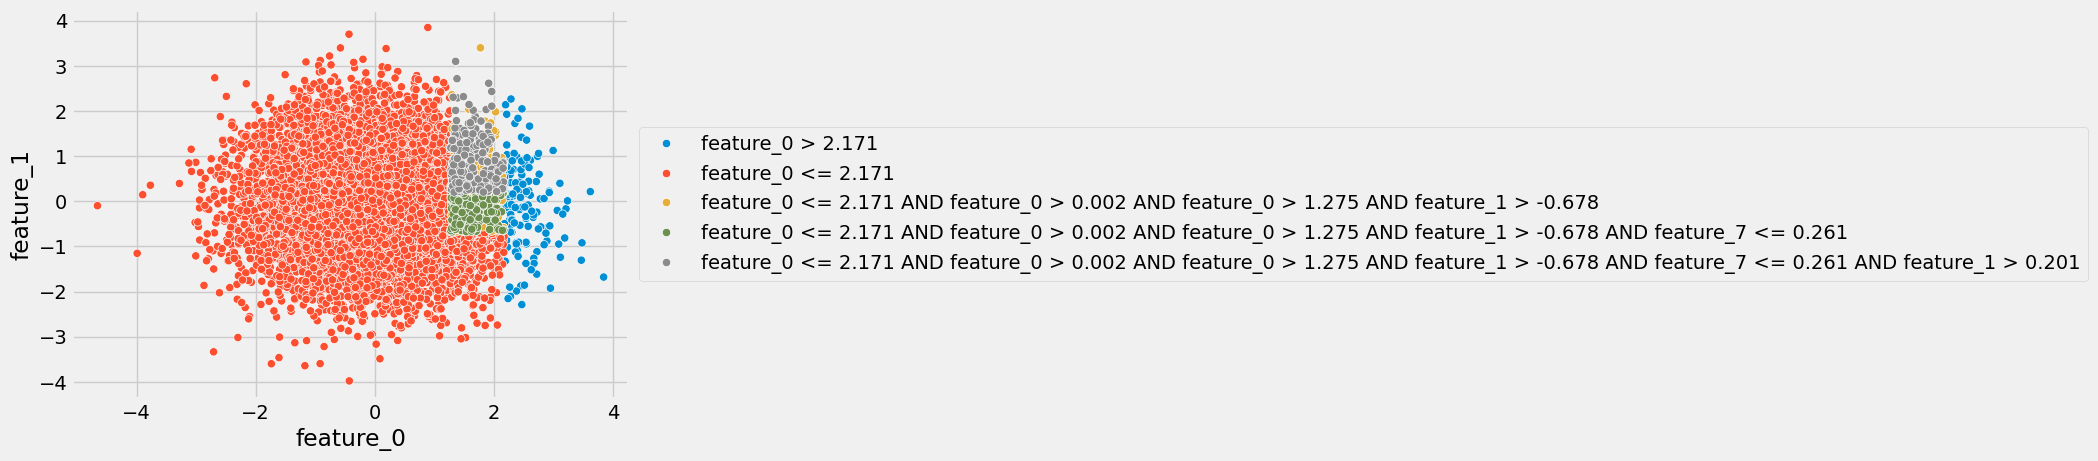

In [82]:
# create a single plot with the 5 classes based on each recommendation
import polars as pl

df_plot = pd.DataFrame(columns=['feature_0', 'feature_1', 'condition'])
for i in [4,2, 3,1,0]:
    condition = top_ct_p.iloc[i]['condition']
    dt = data.execute(condition)
    dt = dt[['feature_0', 'feature_1']]

    dt = pd.DataFrame(dt, columns=['feature_0', 'feature_1'])
    dt['condition'] = condition

    df_plot = pd.concat([df_plot, dt], ignore_index=True)
    
sns.scatterplot(x='feature_0', y='feature_1', hue='condition', data=df_plot)
# reduce legend size
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

# Visualizations from the CF

In [87]:
top_cf = scores[(scores['algorithm']=='CF')].sort_values('score', ascending=False)
top_cf

,condition,t_est,distance,T0,T1,depth,norm_cate,score,t,features,true_score,algorithm,execution_time
10,feature_0 <= -0.02 AND feature_1 > 1.647 AND f...,20.290,0.00,NaN,NaN,4,1.00,0.60,1.479,4.0,0.60,CF,5.45
11,feature_0 <= 1.287,0.881,0.76,NaN,NaN,1,0.04,0.33,0.609,1.0,0.55,CF,5.45
12,feature_1 <= 1.094,0.760,0.73,NaN,NaN,1,0.04,0.31,0.643,1.0,0.55,CF,5.45
13,feature_0 > -0.95,1.053,0.70,NaN,NaN,1,0.05,0.31,1.107,1.0,0.73,CF,5.45
14,feature_0 > -0.909,1.041,0.69,NaN,NaN,1,0.05,0.31,1.125,1.0,0.73,CF,5.45


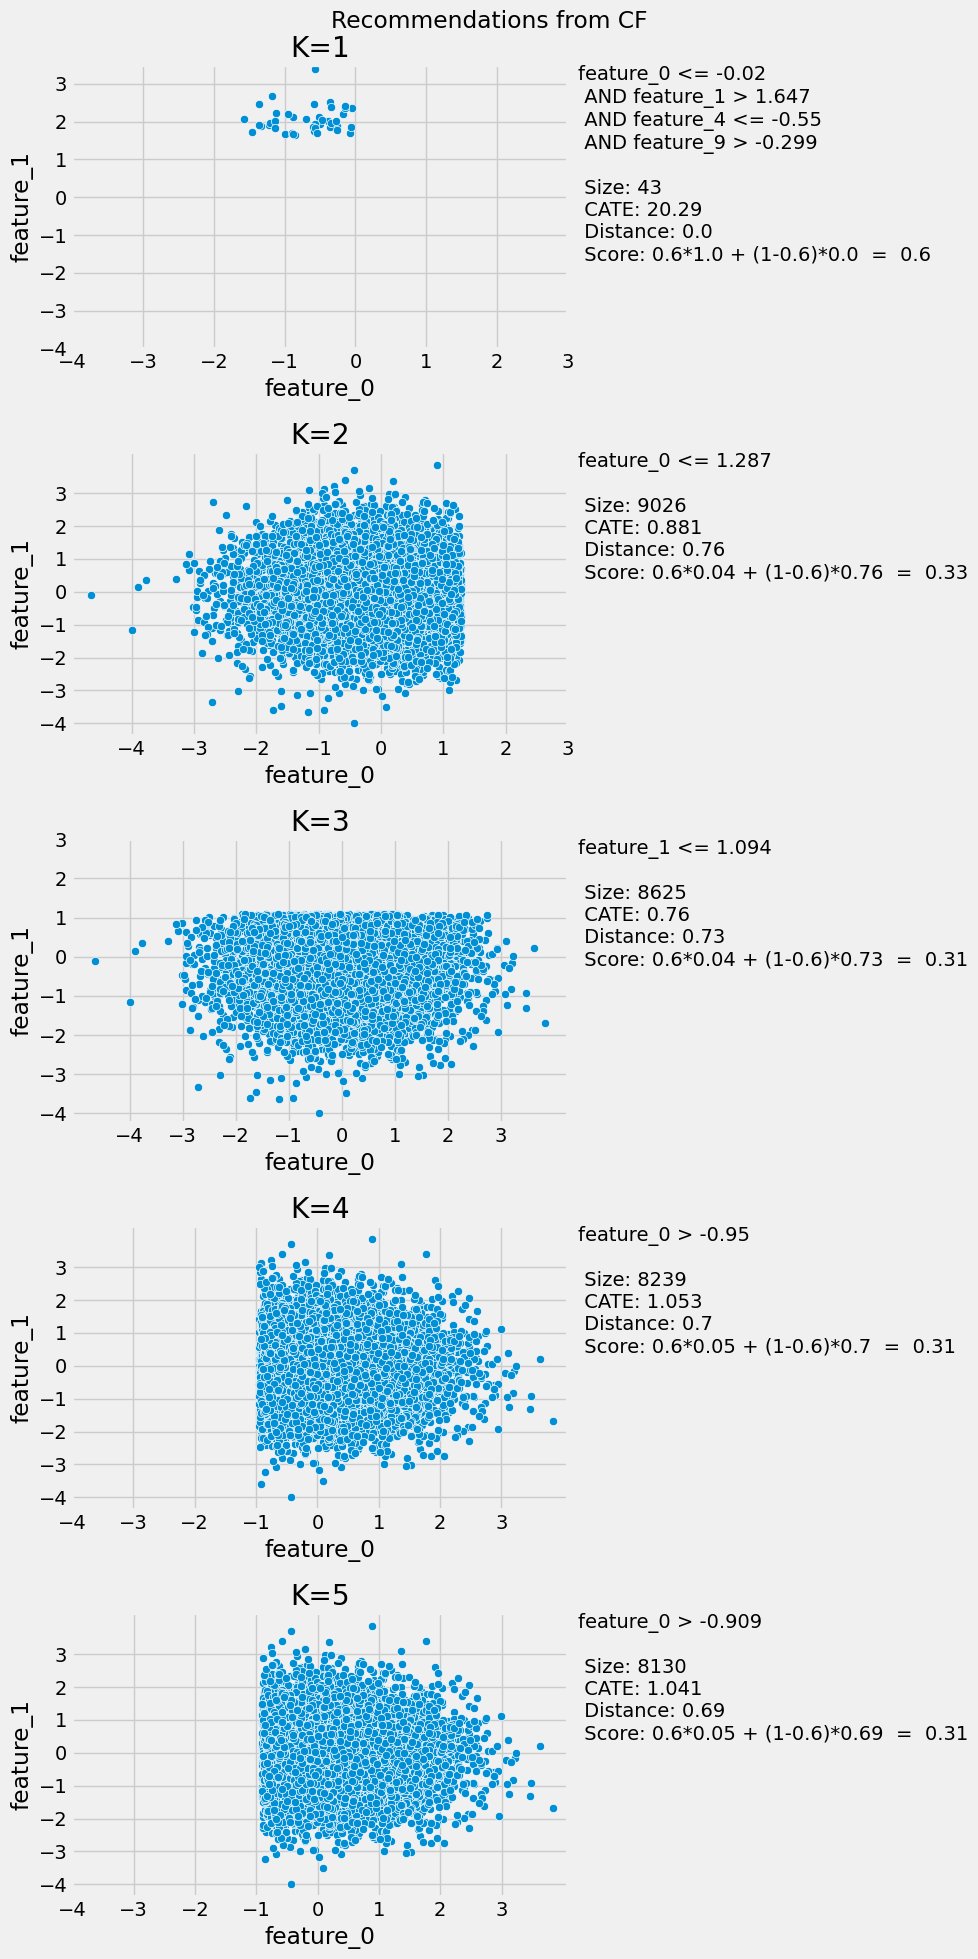

In [88]:
import numpy as np


def visualize_recommendations2(scores, k=5):
    scores = scores.sort_values('score', ascending=False)

    fig, axs = plt.subplots(k, 1, figsize=(10,20), tight_layout = True)
    fig.suptitle('Recommendations from '+ scores.iloc[0]['algorithm'])
    for i in range(k):
        topK = scores.iloc[i]
        dt = data.execute(topK['condition'])[['feature_0', 'feature_1']]
        topK['condition'] = topK['condition'].replace('AND', '\n AND')

        dt = pd.DataFrame(dt, columns=['feature_0', 'feature_1'])

        sns.scatterplot(x='feature_0', y='feature_1', data=dt, ax=axs[i])
        
        axs[i].set_title('K='+str(i+1))
        axs[i].set_xticks(np.arange(-4, 4, 1))
        # axs[i].tick_params(axis='x', rotation=45)
        axs[i].set_yticks(np.arange(-4, 4, 1))
        # axs[i].set_xlabel("treatment")
        # axs[i].set_ylabel("outcome")

        outer_text = f"{topK['condition']} \n\n Size: {dt.shape[0]} \n CATE: {str(topK['t_est'])} \n Distance: {str(topK['distance'])}\n Score: 0.6*{str(topK['norm_cate'])} + (1-0.6)*{str(topK['distance'])}  =  {str(round(topK['score'],2))}"
        axs[i].annotate(outer_text, xy=(1, 1), xycoords='axes fraction', xytext=(1.02, 1), textcoords='axes fraction', ha='left', va='top')


visualize_recommendations2(top_cf)